# Notebook 4 — Granular Error Drivers

Notebooks 1–3 showed that smaller geographies and small subgroup cells have higher uncertainty. This notebook asks why.

**Part A** tests whether population size explains much of the geography effect. **Part B** tests whether combining six tiny Black 65+ cells into one tract-level total improves reliability.

**CV (coefficient of variation)** means standard error as a fraction of the estimate: `CV = SE / estimate`. For ACS margins of error, `SE = MOE / 1.645` because ACS MOEs are 90% confidence intervals. Source: Census Bureau, *Quality Standards Metrics Definitions*.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != 'JL_Analysis':
    NOTEBOOK_DIR = NOTEBOOK_DIR / 'analysis' / 'JL_Analysis'
sys.path.insert(0, str(NOTEBOOK_DIR))

from helpers import (
    GEO_LABELS,
    GEO_LEVELS,
    VARIABLE_GROUPS,
    VARIABLES,
    build_cv_long,
    combine_moes_rss,
    compute_cv,
    estimate_moe_cols,
    load_acs,
)

plt.rcParams['figure.dpi'] = 110

## Part A — Is population size the real driver?

**Population size** is the number of people in the row's geography. We use `B01003_001E` (total population estimate) as a proxy for how much sample is available in that geography. This is only a denominator/proxy here; we do not require the total-population MOE to exist, because controlled population estimates can have missing MOEs for reasons unrelated to this question.

The model below fits `log(CV) ~ log(population)`. In plain English, the slope says how fast relative uncertainty falls as population grows. A slope near `-0.5` would match the common sampling pattern that uncertainty shrinks roughly with the square root of population size.

In [2]:
cv_with_population = []
pop_col, _ = estimate_moe_cols('B01003_001')

for level in GEO_LEVELS:
    cv = build_cv_long(level)
    acs = load_acs(level)
    population_lookup = acs[['NAME', pop_col]].copy()
    population_lookup['geography_level'] = level
    population_lookup['population'] = pd.to_numeric(population_lookup[pop_col], errors='coerce')
    if population_lookup[['geography_level', 'NAME']].duplicated().any():
        raise ValueError(f'Duplicate population lookup rows for {level}')
    joined = cv.merge(
        population_lookup[['geography_level', 'NAME', 'population']],
        on=['geography_level', 'NAME'],
        how='left',
        validate='many_to_one',
    )
    cv_with_population.append(joined)

cv_population = pd.concat(cv_with_population, ignore_index=True)
analysis_df = cv_population.dropna(subset=['cv', 'population']).copy()
analysis_df = analysis_df[(analysis_df['cv'] > 0) & (analysis_df['population'] > 0)]
analysis_df['log_population'] = np.log(analysis_df['population'])
analysis_df['log_cv'] = np.log(analysis_df['cv'])
analysis_df = analysis_df[np.isfinite(analysis_df['log_population']) & np.isfinite(analysis_df['log_cv'])]
analysis_df['Geography level'] = analysis_df['geography_level'].map(GEO_LABELS)

print(f'Rows with valid CV and population proxy: {len(analysis_df):,}')
display(
    analysis_df.groupby(['Geography level', 'variable_group'])
    .agg(n=('cv', 'count'), median_population=('population', 'median'), median_cv=('cv', 'median'))
    .round(3)
)

Rows with valid CV and population proxy: 23,330


n  median_population  median_cv
Geography level variable_group                                    
Block group     income          5785             1356.0      0.204
                population      6528             1321.0      0.192
Census tract    income          2109             4178.0      0.128
                population      2172             4173.0      0.079
                poverty         2161             4178.0      0.383
                subgroup        4411             4268.0      0.886
County          income            21           467805.0      0.014
                poverty           21           467805.0      0.046
                subgroup         122           467805.0      0.114

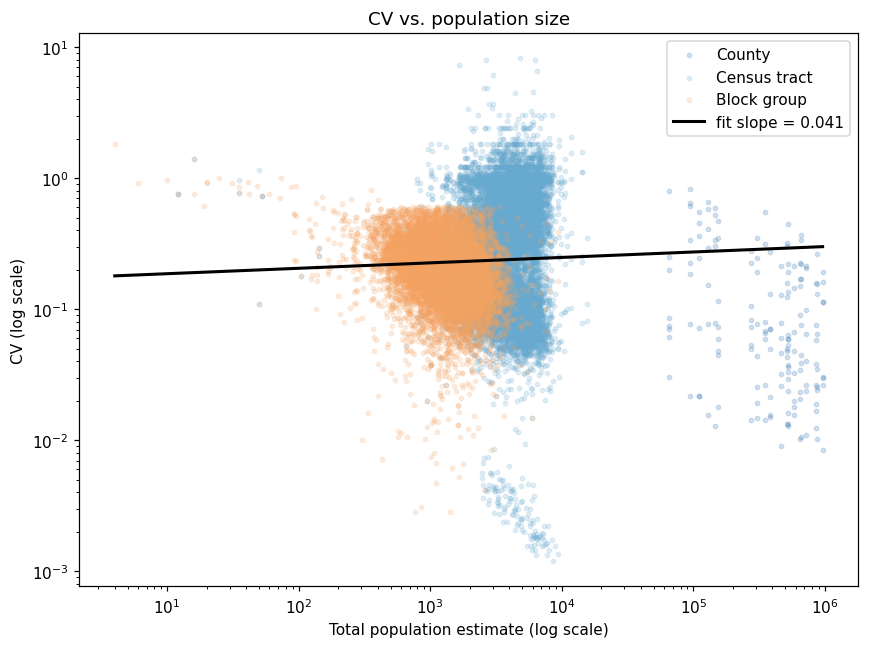

### Part A takeaway

The fitted slope is **0.041** (standard error **0.007**) with R-squared **0.002**. That means a 1% increase in population is associated with almost no average change in CV. Population size alone does not explain the pooled geography pattern; variable type and table availability are also shaping the result. Geography level is still useful, but this simple pooled model should not be treated as proof that population size by itself drives all ACS reliability differences. It also does not hold variable type constant: subgroup cells have structurally high CVs and are not available at block-group level, so a cleaner next test would fit this relationship within each variable group.

In [3]:
coeffs, cov = np.polyfit(analysis_df['log_population'], analysis_df['log_cv'], 1, cov=True)
slope, intercept = coeffs
slope_se = float(np.sqrt(cov[0, 0]))
fitted = intercept + slope * analysis_df['log_population']
ss_res = float(((analysis_df['log_cv'] - fitted) ** 2).sum())
ss_tot = float(((analysis_df['log_cv'] - analysis_df['log_cv'].mean()) ** 2).sum())
r_squared = 1 - (ss_res / ss_tot)

fig, ax = plt.subplots(figsize=(8, 6))
colors = {'county': '#2166ac', 'tract': '#67a9cf', 'block_group': '#f4a261'}
for level in GEO_LEVELS:
    sub = analysis_df[analysis_df['geography_level'] == level]
    ax.scatter(sub['population'], sub['cv'], s=8, alpha=0.18, color=colors[level], label=GEO_LABELS[level])
x_line_log = np.linspace(analysis_df['log_population'].min(), analysis_df['log_population'].max(), 100)
y_line = np.exp(intercept + slope * x_line_log)
ax.plot(np.exp(x_line_log), y_line, color='black', linewidth=2, label=f'fit slope = {slope:.3f}')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Total population estimate (log scale)')
ax.set_ylabel('CV (log scale)')
ax.set_title('CV vs. population size')
ax.legend()
plt.tight_layout()
plt.show()

if slope <= -0.35:
    direction_text = f'a {abs(slope):.2f}% decrease in CV'
    slope_text = 'Population size explains a large part of the geography effect.'
elif slope <= -0.05:
    direction_text = f'a {abs(slope):.2f}% decrease in CV'
    slope_text = 'Population size helps, but variable type and other factors also matter.'
elif slope <= 0.05:
    direction_text = 'almost no average change in CV'
    slope_text = 'Population size alone does not explain the pooled geography pattern; variable type and table availability are also shaping the result.'
else:
    direction_text = f'a {slope:.2f}% increase in CV'
    slope_text = 'Population size is not explaining the pooled pattern in the expected direction; variable mix and table availability are dominating this simple model.'
display(Markdown(
    f"### Part A takeaway\n\n"
    f"The fitted slope is **{slope:.3f}** (standard error **{slope_se:.3f}**) "
    f"with R-squared **{r_squared:.3f}**. "
    f"That means a 1% increase in population is associated with {direction_text}. "
    f"{slope_text} Geography level is still useful, but this simple "
    f"pooled model should not be treated as proof that population size by itself "
    f"drives all ACS reliability differences. It also does not hold variable "
    f"type constant: subgroup cells have structurally high CVs and are not "
    f"available at block-group level, so a cleaner next test would fit this "
    f"relationship within each variable group."
))

## Part B — Combining six Black 65+ cells with RSS MOE

**Root-sum-of-squares (RSS) MOE combination** means we add estimates normally, but combine margins of error by squaring each MOE, adding the squares, and taking the square root: `MOE_sum = sqrt(MOE_1^2 + MOE_2^2 + ... + MOE_k^2)`. This is the Census Bureau's standard approximation for summing ACS estimates. It assumes the component MOEs are available and treats the component estimates as approximately independent for this calculation, so we treat any tract with a missing component estimate/MOE pair as missing for the combined measure. After that, we compute the combined CV the same way as before: `combined CV = (combined MOE / 1.645) / combined estimate`.

In [4]:
subgroup_codes = VARIABLE_GROUPS['subgroup']
tract = load_acs('tract')
est_cols = [estimate_moe_cols(code)[0] for code in subgroup_codes]
moe_cols = [estimate_moe_cols(code)[1] for code in subgroup_codes]

combined_estimate, combined_moe = combine_moes_rss(tract[est_cols], tract[moe_cols])
missing_combined_rows = int(combined_estimate.isna().sum())
if missing_combined_rows:
    print(f'{missing_combined_rows:,} tracts have at least one missing/invalid component estimate or MOE; combined CV is left blank for those rows.')
else:
    print('All tracts have complete valid component estimates and MOEs for RSS combination.')
combined_cv = compute_cv(combined_estimate, combined_moe, var_code=subgroup_codes[0])
combined = pd.DataFrame({
    'NAME': tract['NAME'],
    'combined_estimate': combined_estimate,
    'combined_moe': combined_moe,
    'combined_cv': combined_cv,
})

individual = build_cv_long('tract')
individual = individual[individual['variable_code'].isin(subgroup_codes)].dropna(subset=['cv'])

def summarize_cv(label: str, series: pd.Series) -> dict:
    s = series.dropna()
    return {
        'CV series': label,
        'n': len(s),
        'median_cv': s.median(),
        'p75_cv': s.quantile(0.75),
        'p90_cv': s.quantile(0.90),
        'share_cv_at_or_below_0_30': (s <= 0.30).mean(),
    }

rss_summary = pd.DataFrame([
    summarize_cv('Individual Black 65+ cells (pooled)', individual['cv']),
    summarize_cv('RSS combined Black 65+ tract total', combined['combined_cv']),
])
display(rss_summary.round(3))

All tracts have complete valid component estimates and MOEs for RSS combination.


,CV series,n,median_cv,p75_cv,p90_cv,share_cv_at_or_below_0_30
0,Individual Black 65+ cells (pooled),4411,0.886,1.013,1.216,0.013
1,RSS combined Black 65+ tract total,1596,0.714,1.350,2.875,0.122


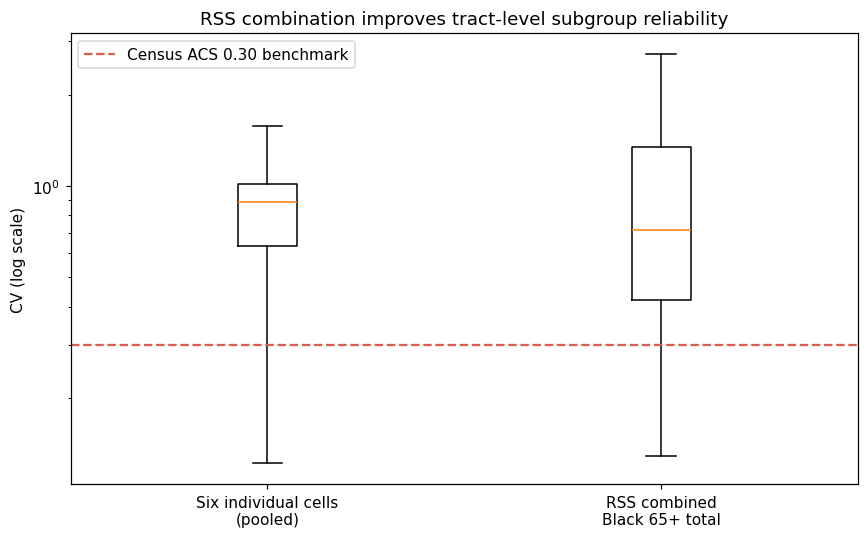

### Part B takeaway

The pooled individual cells have median CV **0.886**, while the RSS-combined Black 65+ tract total has median CV **0.714**. The individual-cell median is about **1.2x** the combined median. Using the Census ACS 0.30 benchmark, **1.3%** of individual-cell CVs are at or below the benchmark versus **12.2%** of RSS-combined tract totals. In plain English: aggregating tiny cells does not remove uncertainty, but it makes this subgroup measure much more usable than the six separate age-by-sex cells.

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_data = [individual['cv'].dropna().values, combined['combined_cv'].dropna().values]
ax.boxplot(plot_data, tick_labels=['Six individual cells\n(pooled)', 'RSS combined\nBlack 65+ total'], showfliers=False)
ax.axhline(0.30, color='#d6604d', linestyle='--', linewidth=1.5, label='Census ACS 0.30 benchmark')
ax.set_yscale('log')
ax.set_ylabel('CV (log scale)')
ax.set_title('RSS combination improves tract-level subgroup reliability')
ax.legend()
plt.tight_layout()
plt.show()

individual_median_cv = float(rss_summary.loc[0, 'median_cv'])
combined_median_cv = float(rss_summary.loc[1, 'median_cv'])
median_ratio = individual_median_cv / combined_median_cv
individual_share_benchmark = float(rss_summary.loc[0, 'share_cv_at_or_below_0_30'])
combined_share_benchmark = float(rss_summary.loc[1, 'share_cv_at_or_below_0_30'])

display(Markdown(
    f"### Part B takeaway\n\n"
    f"The pooled individual cells have median CV **{individual_median_cv:.3f}**, "
    f"while the RSS-combined Black 65+ tract total has median CV "
    f"**{combined_median_cv:.3f}**. The individual-cell median is about "
    f"**{median_ratio:.1f}x** the combined median. Using the Census ACS "
    f"0.30 benchmark, **{individual_share_benchmark:.1%}** of individual-cell "
    f"CVs are at or below the benchmark versus **{combined_share_benchmark:.1%}** "
    f"of RSS-combined tract totals. In plain English: aggregating tiny cells "
    f"does not remove uncertainty, but it makes this subgroup measure much more "
    f"usable than the six separate age-by-sex cells."
))

### Final Takeaway
Part A
We plot county, tract, and block group together because they are nested geography levels: counties are large, tracts are smaller, block groups are smallest. In this NJ dataset that means about 21 counties, 2,181 tracts, and 6,599 block groups. The chart tests whether all three levels fall on one shared population-size curve. If they did, we could say: “granular geography is noisier mostly because smaller places have smaller populations.”

The key finding was: they did not line up that cleanly. The fitted slope was 0.041, with R² 0.002, meaning population size alone explained almost none of the CV variation in this pooled model. That does not mean population size is irrelevant. It means this specific pooled model mixed together very different variable types: total population, income, poverty, and detailed subgroup counts. Those variables have different ACS behavior, and some are not even available at block-group level. So variable type and table availability are probably dominating the simple population-size relationship.

A stronger next version would model CV more comprehensively, for example:

log(CV) ~ log(population) + log(estimate size) + geography level + variable group + interactions
The most important target variables are probably:

estimate size: small counts often have high CV even inside moderately populated tracts.
variable group: income, poverty, total population, and detailed race-age cells behave differently.
geography level: county/tract/block group still matters as a communication category.
subgroup share: rare populations in a geography are usually noisier.
availability/suppression: whether ACS publishes the table at that geography level is itself a signal.
So yes, the next model should separate “population size of the place” from “size of the thing being estimated.” That second one may be the stronger driver.

Part B
RSS means root-sum-of-squares. Plain English: when we add several ACS estimates together, we add the estimates normally, but we do not add the MOEs normally. We combine the MOEs like this:

combined MOE = sqrt(MOE_1^2 + MOE_2^2 + ... + MOE_k^2)
This matters because simple MOE addition would exaggerate uncertainty. RSS is the Census-standard approximation for summing ACS estimates. It lets us ask: “If six tiny cells are individually unreliable, does combining them into one broader group produce a more useful estimate?”

Black 65+ was used because the project had already pulled six detailed Black age-sex cells, and HANDOFF.md explicitly deferred the question of combining them. The six cells were:

- B01001B_014: Black male 65-74
- B01001B_015: Black male 75-84
- B01001B_016: Black male 85+
- B01001B_029: Black female 65-74
- B01001B_030: Black female 75-84
- B01001B_031: Black female 85+

One clarification: we did not personally “sample” those six cells. ACS sampled households; we used six published ACS estimate/MOE columns.

The logic was to stress-test a small, policy-relevant subgroup. Older adults by race at tract level are exactly the kind of demographic slice a planner might care about, but also exactly the kind of estimate that can become unreliable in small geographies.

The result makes sense: individual cells were very noisy, with pooled median CV 0.886. After RSS aggregation, the combined Black 65+ tract total had median CV 0.714. That is better, but still high. The share meeting the Census 0.30 benchmark improved from 1.3% to 12.2%, so aggregation helps, but it does not magically make the subgroup reliable everywhere.

You are also right to ask: why not compare to a similar-size population? That would be a better causal comparison. Part B is currently a before/after aggregation demo, not a matched-population experiment. A stronger next analysis would compare groups with similar estimate sizes, for example Black 65+ tracts vs another subgroup binned into the same count ranges. That would help separate “this group is noisy because it is small” from “this table/demographic has extra uncertainty for other reasons.”